# Project 1: Predictive Maintenance
## Regression
Download the AI4I 2020 Predictive Maintenance
Dataset from UCI. Train a Linear Regression
and a Polynomial Regression (degree 2 and 3)
to predict machine tool wear (TWF target).
Compare all three models' RMSE and R² on the
test set. Plot actual vs. predicted and residuals
for the best model.
Skills: sklearn LinearRegression,
PolynomialFeatures, Pipeline, metrics

                                                   0
0                                                  2
1  {'Degree': 1, 'RMSE': 65.37917394764654, 'R2':...
2  {'Degree': 2, 'RMSE': 65.34790441955603, 'R2':...
3  {'Degree': 3, 'RMSE': 65.57128726537688, 'R2':...


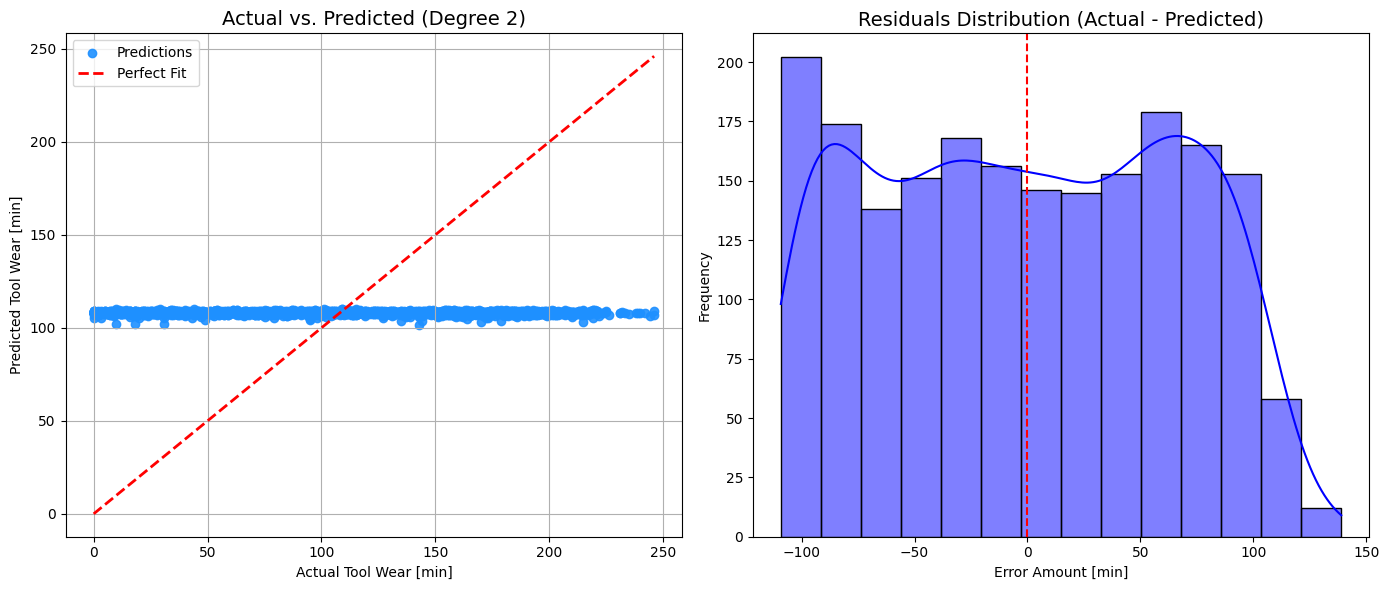

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv("ai4i2020.csv")
X = df[['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]']]
y = df['Tool wear [min]']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Define our 3 Models
degrees = [1, 2, 3]
models = {}

for deg in degrees:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=deg)),
        ('regressor', LinearRegression())
    ])
    models[deg] = model
    model.fit(X_train, y_train)
   

# 3. Compare Results
results = [2]
for deg, model in models.items():
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({'Degree': deg, 'RMSE': rmse, 'R2': r2})

print(pd.DataFrame(results))
# X
# print(y)
# 1. Generate predictions for the best model (Degree 1)
best_model = models[1]
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

# 2. Setup the figure
plt.figure(figsize=(14, 6))

# --- PLOT 1: ACTUAL VS. PREDICTED ---
plt.subplot(1, 2, 1)
plt.scatter(y_test,  y_pred, alpha=0.9, color='dodgerblue', label='Predictions')

# Add the Identity Line (Perfect Fit)
line_coords = np.linspace(y_test.min(), y_test.max(), 100)
# This is the specific command that draws the "Line of Truth" on your scatter plot 
plt.plot(line_coords, line_coords, color="red", linestyle="--", linewidth=2, label='Perfect Fit')

plt.title("Actual vs. Predicted (Degree 2)", fontsize=14)
plt.xlabel("Actual Tool Wear [min]")
plt.ylabel("Predicted Tool Wear [min]")
plt.legend()
plt.grid(alpha=1)

# --- PLOT 2: RESIDUALS PLOT ---
plt.subplot(1, 2,2)
sns.histplot(residuals, kde=True, color="blue")
plt.axvline(0, color='red', linestyle='--')
plt.title("Residuals Distribution (Actual - Predicted)", fontsize=14)
plt.xlabel("Error Amount [min]")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()